# Taller 2: Análisis Grad-CAM de la CNN (Fashion-MNIST)

Este notebook **ejecuta de principio a fin** el análisis de interpretabilidad del modelo
`SmallCNN` entrenado en el Taller 2 (clasificación de imágenes con redes convolucionales).

## ¿Qué es Grad-CAM?

Grad-CAM (*Gradient-weighted Class Activation Mapping*, Selvaraju et al., 2016) produce
un mapa de calor que indica **qué regiones de la imagen sustentan la predicción**: pesa cada
mapa de activación de la última capa convolucional por el gradiente de la clase predicha y
aplica ReLU sobre la combinación. No requiere reentrenar ni modificar la arquitectura.

## Contenido

1. Configuración del entorno
2. Carga de datos (split de test del Taller 1)
3. Carga del modelo entrenado
4. Implementación de Grad-CAM
5. Selección de ejemplos (aciertos y errores más confiados)
6. Visualización
7. Interpretación de resultados

> **Requisitos:** entorno del proyecto instalado (`pip install -e .` desde `Workshop_2/`).
> Las rutas se adaptan según se abra Jupyter desde `notebooks/` o desde la raíz del taller.
> El checkpoint utilizado es `checkpoints/model_best.pt`.

# 1. Configuración del entorno

In [1]:
# !pip install torch torchvision numpy matplotlib scikit-learn

In [2]:
import gzip
import json
import os
import struct
from pathlib import Path

# Ruta adaptable a ejecución desde notebooks/ o desde la raíz Workshop_2/
if Path.cwd().name == "notebooks":
    os.chdir("..")
BASE = Path.cwd()

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

# Análisis pequeño: CPU es suficiente y evita problemas de hooks de backward en MPS.
# Puedes cambiarlo a "mps" o "cuda" si tu entorno lo soporta.
DEVICE = torch.device("cpu")
torch.manual_seed(42)

print("torch:", torch.__version__)
print("device:", DEVICE)
print("base del taller:", BASE)

torch: 2.14.0
device: cpu
base del taller: /Users/jhojan/Documents/Universidad/Semestre10/MachineLearning/Workshops/MachineLearning/Workshop_2


# 2. Carga de datos (split de test)

Se reutilizan las imágenes IDX originales del Taller 1 (`Workshop_1/code/data`) y la
partición estratificada **70/15/15** con semilla 42 guardada en `data/splits.json`,
exactamente la misma que usó el entrenamiento y la evaluación del Taller 2.

**Lectura de los archivos IDX originales** (misma verificación de cabeceras que el Taller 1)

In [3]:
RAW_DIR = (BASE / ".." / "Workshop_1" / "code" / "data").resolve()


def load_idx_images(path):
    with gzip.open(path, "rb") as fh:
        magic, n, rows, cols = struct.unpack(">IIII", fh.read(16))
        assert magic == 2051, f"magic inesperado {magic} en {path}"
        buffer = fh.read()
    return np.frombuffer(buffer, dtype=np.uint8).reshape(n, rows, cols)


def load_idx_labels(path):
    with gzip.open(path, "rb") as fh:
        magic, n = struct.unpack(">II", fh.read(8))
        assert magic == 2049, f"magic inesperado {magic} en {path}"
        buffer = fh.read()
    return np.frombuffer(buffer, dtype=np.uint8).reshape(n)


if RAW_DIR.exists():
    train_x = load_idx_images(RAW_DIR / "train-images-idx3-ubyte.gz")
    train_y = load_idx_labels(RAW_DIR / "train-labels-idx1-ubyte.gz")
    test_x = load_idx_images(RAW_DIR / "t10k-images-idx3-ubyte.gz")
    test_y = load_idx_labels(RAW_DIR / "t10k-labels-idx1-ubyte.gz")
else:  # respaldo: descarga vía torchvision si los archivos locales no están disponibles
    from torchvision.datasets import FashionMNIST
    ds_train = FashionMNIST(root=BASE / "data" / "raw", train=True, download=True)
    ds_test = FashionMNIST(root=BASE / "data" / "raw", train=False, download=True)
    train_x, train_y = ds_train.data.numpy(), ds_train.targets.numpy()
    test_x, test_y = ds_test.data.numpy(), ds_test.targets.numpy()

images = np.concatenate([train_x, test_x], axis=0)
labels = np.concatenate([train_y, test_y], axis=0)
print("imágenes:", images.shape, "| etiquetas:", labels.shape, "| rango:", images.min(), "-", images.max())

imágenes: (70000, 28, 28) | etiquetas: (70000,) | rango: 0 - 255


**Partición estratificada (se reutiliza la del Taller 2; se recrea si no existe)**

In [4]:
splits_path = BASE / "data" / "splits.json"

if splits_path.exists():
    splits = json.loads(splits_path.read_text())["indices"]
    print("split cargado desde data/splits.json:", {k: len(v) for k, v in splits.items()})
else:
    from sklearn.model_selection import train_test_split
    idx = np.arange(len(labels))
    train_idx, rest_idx = train_test_split(idx, test_size=0.30, stratify=labels, random_state=42)
    val_idx, test_idx = train_test_split(rest_idx, test_size=0.50, stratify=labels[rest_idx], random_state=42)
    splits = {
        "train": [int(i) for i in train_idx],
        "val": [int(i) for i in val_idx],
        "test": [int(i) for i in test_idx],
    }
    print("split recreado (seed=42):", {k: len(v) for k, v in splits.items()})

test_idx = np.array(splits["test"])
test_images = images[test_idx]
test_labels = labels[test_idx]
print("conjunto de test:", test_images.shape)

split cargado desde data/splits.json: {'train': 49000, 'val': 10500, 'test': 10500}
conjunto de test: (10500, 28, 28)


**Inspección visual: una muestra de test por clase**

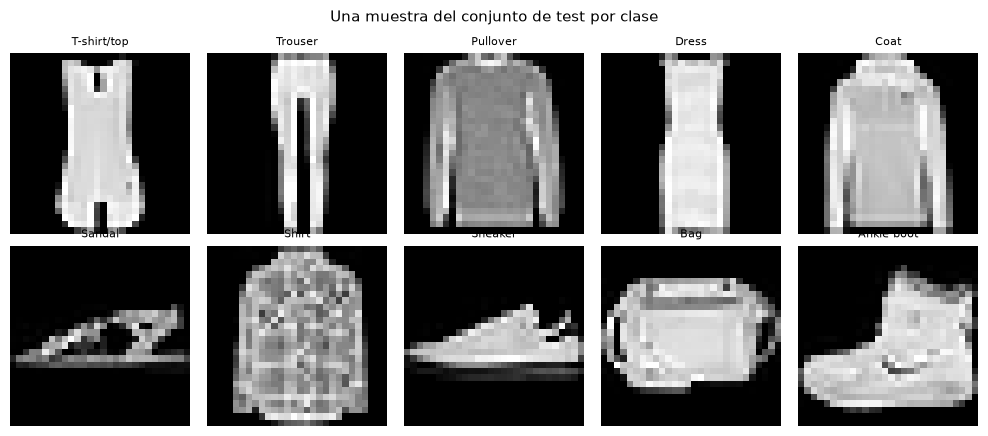

In [5]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for ax, class_id in zip(axes.flat, range(10)):
    first = np.where(test_labels == class_id)[0][0]
    ax.imshow(test_images[first], cmap="gray")
    ax.set_title(CLASS_NAMES[class_id], fontsize=8)
    ax.axis("off")
fig.suptitle("Una muestra del conjunto de test por clase", fontsize=11)
plt.tight_layout()
plt.show()

# 3. Carga del modelo entrenado

La arquitectura `SmallCNN` se define aquí mismo (idéntica a `src/model.py`) para que el
notebook sea autocontenido. El checkpoint guarda el `state_dict`, las clases, las
estadísticas de normalización y la mejor métrica de validación.

In [6]:
def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )


class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, head_dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(1, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2),      # 28 -> 14
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2),      # 14 -> 7
            conv_block(64, 128),
            nn.MaxPool2d(2),      # 7 -> 3
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(head_dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))

In [7]:
CKPT_PATH = BASE / "checkpoints" / "model_best.pt"
checkpoint = torch.load(CKPT_PATH, map_location="cpu")
assert checkpoint["model_name"] == "smallcnn", "este notebook analiza el checkpoint SmallCNN"

model = SmallCNN(num_classes=len(checkpoint["classes"]))
model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE).eval()

n_params = sum(p.numel() for p in model.parameters())
vm = checkpoint["val_metrics"]
print(f"checkpoint : {CKPT_PATH.name} | época {checkpoint['epoch']}")
print(f"validación : acc={vm['accuracy']:.4f} | macro F1={vm['f1_macro']:.4f}")
print(f"parámetros : {n_params:,}")

checkpoint : model_best.pt | época 29
validación : acc=0.9333 | macro F1=0.9332
parámetros : 140,458


# 4. Implementación de Grad-CAM

Para una clase objetivo $c$ y los mapas de activación $A^k$ de la última capa convolucional:

$$\alpha_k = \frac{1}{Z}\sum_i\sum_j \frac{\partial y^c}{\partial A^k_{ij}},
\qquad
L^c_{\text{Grad-CAM}} = \text{ReLU}\Big(\sum_k \alpha_k A^k\Big)$$

- $\alpha_k$: importancia de cada mapa $k$ (promedio global del gradiente).
- ReLU: conserva solo la evidencia **a favor** de la clase.
- La capa objetivo es la **última convolución** (`features[6]`, mapas de $7\times7$): mejor
  compromiso entre semántica de alto nivel y detalle espacial.

Se usan *hooks* de PyTorch para capturar activaciones (forward) y gradientes (backward).

In [8]:
class GradCAM:
    '''Grad-CAM mediante hooks de forward/backward (sin modificar el modelo).'''

    def __init__(self, model, target_layer):
        self.model = model
        self.activation = None
        self.gradient = None
        self._h_fwd = target_layer.register_forward_hook(self._on_forward)
        self._h_bwd = target_layer.register_full_backward_hook(self._on_backward)

    def _on_forward(self, module, inputs, output):
        self.activation = output

    def _on_backward(self, module, grad_input, grad_output):
        self.gradient = grad_output[0]

    def __call__(self, image, class_idx=None):
        '''image: tensor (28, 28) o (1, 28, 28). Devuelve (cam, clase, probabilidades).'''
        if image.dim() == 2:
            image = image.unsqueeze(0)
        self.model.zero_grad(set_to_none=True)
        logits = self.model(image.unsqueeze(0))
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1))
        logits[0, class_idx].backward()

        weights = self.gradient.mean(dim=(2, 3), keepdim=True)      # alpha_k
        cam = F.relu((weights * self.activation).sum(dim=1))[0]     # ReLU(sum alpha_k A^k)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        probs = torch.softmax(logits.detach(), dim=1)[0]
        return cam.detach().cpu().numpy(), class_idx, probs.cpu()

    def close(self):
        self._h_fwd.remove()
        self._h_bwd.remove()


TARGET_LAYER = model.features[6]   # última capa convolucional (antes del pooling final)
gradcam = GradCAM(model, TARGET_LAYER)
print("capa objetivo:", TARGET_LAYER[0])

capa objetivo: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


In [9]:
FMNIST_MEAN, FMNIST_STD = 0.2860402, 0.3530242


def to_display(image_tensor):
    '''Desnormaliza un tensor (1, 28, 28) para visualizarlo en escala de grises.'''
    gray = image_tensor[0].numpy()
    return np.clip(gray * FMNIST_STD + FMNIST_MEAN, 0.0, 1.0)


def predict(image_np):
    '''Predice una imagen uint8 (28, 28) y devuelve (clase, probabilidad, tensor normalizado).'''
    tensor = torch.from_numpy(image_np).float().div(255.0)
    tensor = (tensor - FMNIST_MEAN) / FMNIST_STD
    _, class_idx, probs = gradcam(tensor, class_idx=None)
    return class_idx, float(probs[class_idx]), tensor

# 5. Selección de ejemplos

Se recorren las predicciones de todo el test set y se eligen:

- **3 aciertos diversos** (Shirt, T-shirt/top, Pullover…): evidencia de representaciones útiles.
- **3 errores más confiados** de las clases superiores (Shirt / T-shirt/top): los casos que más
  información dan para el análisis de confusión del informe.

In [10]:
model.eval()
preds, probs_all = [], []
with torch.no_grad():
    for start in range(0, len(test_images), 256):
        batch = test_images[start:start + 256]
        tensor = torch.from_numpy(batch).float().div(255.0)
        tensor = (tensor - FMNIST_MEAN) / FMNIST_STD
        logits = model(tensor.unsqueeze(1).to(DEVICE))
        probs = torch.softmax(logits, dim=1).cpu()
        preds.append(probs.argmax(dim=1))
        probs_all.append(probs)

preds = torch.cat(preds).numpy()
probs_all = torch.cat(probs_all).numpy()
acc = (preds == test_labels).mean()
print(f"accuracy en test (recalculada): {acc:.4f}")

accuracy en test (recalculada): 0.9305


In [11]:
miss_ids = {CLASS_NAMES.index("Shirt"), CLASS_NAMES.index("T-shirt/top")}
correct_pool, missed_pool = [], []
for i in range(len(test_labels)):
    true, pred = int(test_labels[i]), int(preds[i])
    if true == pred:
        correct_pool.append((i, true, pred, probs_all[i, pred]))
    elif true in miss_ids:
        missed_pool.append((i, true, pred, probs_all[i, pred]))

# aciertos diversos: uno por clase (en orden de preferencia)
picked_correct = []
for class_name in ("Shirt", "T-shirt/top", "Pullover", "Sneaker", "Bag"):
    class_id = CLASS_NAMES.index(class_name)
    for entry in correct_pool:
        if entry[1] == class_id:
            picked_correct.append(entry)
            break
    if len(picked_correct) == 3:
        break

# errores más confiados
missed_pool.sort(key=lambda e: -e[3])
examples = picked_correct + missed_pool[:3]

print("ejemplos seleccionados:")
for idx, true, pred, prob in examples:
    mark = "acierto" if true == pred else "ERROR  "
    print(f"  [{mark}] test[{idx:5d}]  {CLASS_NAMES[true]:<12} -> {CLASS_NAMES[pred]:<12} p={prob:.3f}")

ejemplos seleccionados:
  [acierto] test[   12]  Shirt        -> Shirt        p=0.931
  [acierto] test[    3]  T-shirt/top  -> T-shirt/top  p=0.975
  [acierto] test[    8]  Pullover     -> Pullover     p=0.999
  [ERROR  ] test[ 9305]  Shirt        -> Coat         p=0.999
  [ERROR  ] test[ 1566]  T-shirt/top  -> Bag          p=0.997
  [ERROR  ] test[ 2110]  Shirt        -> Pullover     p=0.994


# 6. Visualización

**Ejemplo individual, paso a paso** — imagen original, mapa Grad-CAM y superposición

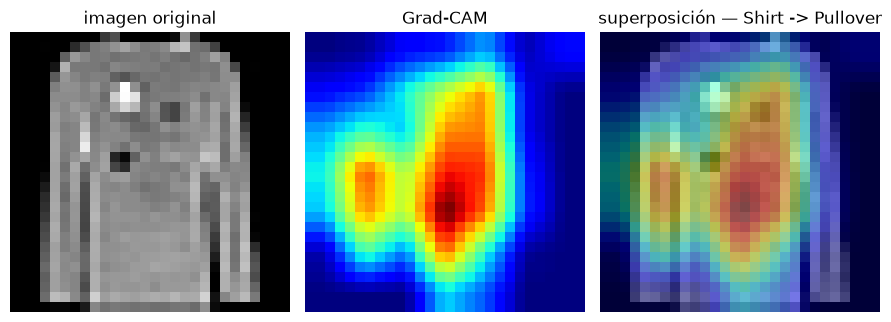

In [12]:
idx, true, pred, prob = examples[-1]   # el error más confiado
tensor = (torch.from_numpy(test_images[idx]).float().div(255.0) - FMNIST_MEAN) / FMNIST_STD
cam, class_idx, probs = gradcam(tensor)
gray = test_images[idx] / 255.0
cam_up = F.interpolate(torch.from_numpy(cam)[None, None], size=(28, 28), mode="bilinear", align_corners=False)[0, 0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
axes[0].imshow(gray, cmap="gray"); axes[0].set_title("imagen original")
axes[1].imshow(cam_up, cmap="jet"); axes[1].set_title("Grad-CAM")
axes[2].imshow(gray, cmap="gray"); axes[2].imshow(cam_up, cmap="jet", alpha=0.45)
axes[2].set_title(f"superposición — {CLASS_NAMES[true]} -> {CLASS_NAMES[class_idx]}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Figura resumen** — fila superior: aciertos; fila inferior: errores más confiados.
Se guarda además en `runs/gradcam_examples.png` (misma figura usada en el informe).

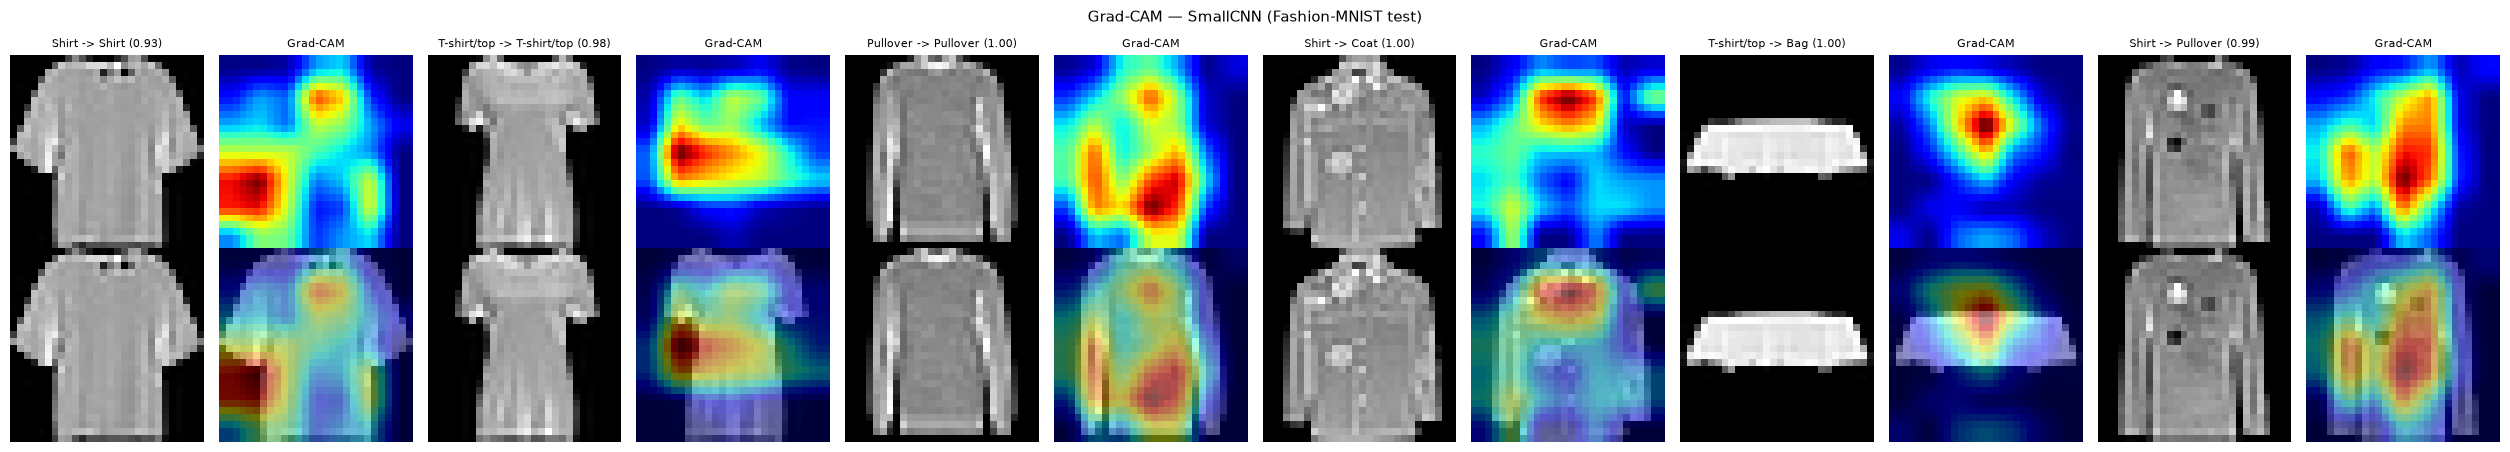

figura guardada en /Users/jhojan/Documents/Universidad/Semestre10/MachineLearning/Workshops/MachineLearning/Workshop_2/runs/gradcam_examples.png


In [13]:
cams, titles = [], []
for idx, true, pred, prob in examples:
    tensor = (torch.from_numpy(test_images[idx]).float().div(255.0) - FMNIST_MEAN) / FMNIST_STD
    cam, _, _ = gradcam(tensor)
    cams.append(cam)
    titles.append(f"{CLASS_NAMES[true]} -> {CLASS_NAMES[pred]} ({prob:.2f})")

n = len(examples)
fig, axes = plt.subplots(2, n * 2, figsize=(2.1 * n * 2, 4.6))
for k, (idx, true, pred, prob) in enumerate(examples):
    gray = test_images[idx] / 255.0
    cam_up = F.interpolate(torch.from_numpy(cams[k])[None, None], size=(28, 28),
                           mode="bilinear", align_corners=False)[0, 0].numpy()
    axes[0, 2 * k].imshow(gray, cmap="gray", vmin=0, vmax=1)
    axes[1, 2 * k].imshow(gray, cmap="gray", vmin=0, vmax=1)
    axes[0, 2 * k + 1].imshow(cam_up, cmap="jet")
    axes[1, 2 * k + 1].imshow(gray, cmap="gray", vmin=0, vmax=1)
    axes[1, 2 * k + 1].imshow(cam_up, cmap="jet", alpha=0.45)
    axes[0, 2 * k].set_title(titles[k], fontsize=8)
    axes[0, 2 * k + 1].set_title("Grad-CAM", fontsize=8)
    for row in (0, 1):
        axes[row, 2 * k].axis("off")
        axes[row, 2 * k + 1].axis("off")
axes[0, 0].set_ylabel("aciertos", fontsize=9)
axes[1, 0].set_ylabel("errores", fontsize=9)
fig.suptitle("Grad-CAM — SmallCNN (Fashion-MNIST test)", fontsize=11)
plt.tight_layout()
runs_dir = BASE / "runs"
runs_dir.mkdir(exist_ok=True)
fig.savefig(runs_dir / "gradcam_examples.png", dpi=150)
plt.show()
print("figura guardada en", runs_dir / "gradcam_examples.png")

# 7. Interpretación de resultados

**Cómo leer las figuras**

- El rojo indica las regiones con mayor peso en la decisión; el azul, menor.
- Si el mapa se concentra en la **prenda** (torso, mangas) y no en el fondo, el modelo
  aprendió características relevantes del dominio.

**Hallazgos de este análisis**

1. **Aciertos:** la atención se concentra sobre la prenda (pecho, torso, mangas), nunca sobre
   el fondo constante — evidencia de representaciones útiles.
2. **Shirt -> Pullover / Coat:** la atención cae en texturas de punto y mangas (información
   compartida entre las clases superiores) en lugar del cuello y el corte que las diferencian.
3. **T-shirt/top -> Bag:** el error más confiado corresponde a un top corto cuya silueta se
   solapa con el cúmulo de "bolso" — un caso genuinamente ambiguo.

**Consistencia con el Taller 1**

Los errores se concentran en las prendas superiores (Shirt, T-shirt/top, Pullover, Coat),
tal como lo anticiparon el PCA y las imágenes promedio del EDA, y como lo confirmaron los
modelos base. La CNN mejora el desempeño general (+5.6 puntos sobre el mejor baseline) pero
no elimina la ambigüedad intrínseca de esas cuatro clases.

**Siguientes pasos**

- Repetir el análisis por clase (mapa promedio por categoría) cuando entrene la variante
  ResNet-18.
- Usar estas figuras en las secciones de *Training Results* y *Analysis* del informe.